In [1]:
import numpy as np

#### 생선의 길이를 사용하여 무게를 예측

In [2]:
fish_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
fish_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 
     1000.0, 1000.0]
     )
   

#### 길이와 무게를 산포도로 표현

In [3]:
import matplotlib.pyplot as plt

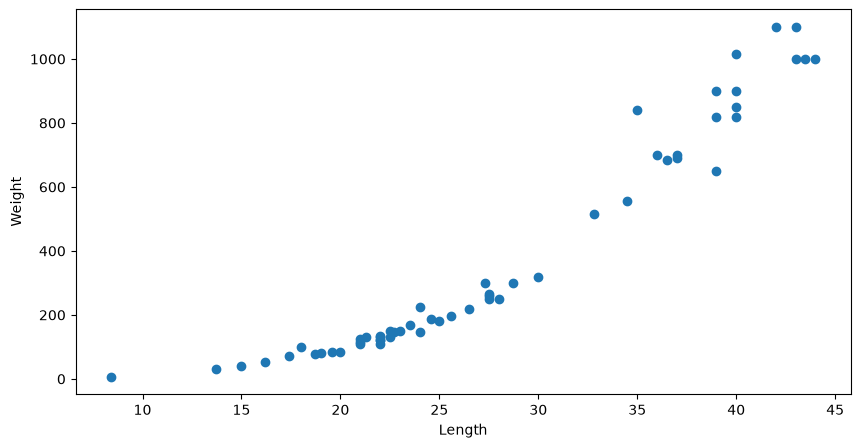

In [4]:
plt.figure(figsize=(10,5))

plt.scatter(fish_length, fish_weight)
plt.xlabel('Length')
plt.ylabel('Weight')
plt.show()

#### Train Set과 Test Set의 분리

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
train_input, test_input, train_target, test_target = \
   train_test_split(
      fish_length,
      fish_weight,
      random_state=42,
      
   )

> 분류 문제가 아니므로 stratify는 사용하지 않는다

In [8]:
# 분리된 결과 확인
print(train_input.shape, test_input.shape)
print(train_target.shape, test_target.shape)

(42,) (14,)
(42,) (14,)


In [9]:
train_input

array([19.6, 22. , 18.7, 17.4, 36. , 25. , 40. , 39. , 43. , 22. , 20. ,
       22. , 24. , 27.5, 43. , 40. , 24. , 21. , 27.5, 40. , 32.8, 26.5,
       36.5, 13.7, 22.7, 15. , 37. , 35. , 28.7, 23.5, 39. , 21. , 23. ,
       22. , 44. , 22.5, 19. , 37. , 22. , 25.6, 42. , 34.5])

In [10]:
# 1열로 구성된 배열로 재구성
train_input = train_input.reshape(-1,1)

In [12]:
train_input.shape

(42, 1)

In [14]:
test_input = test_input.reshape(-1,1)

In [15]:
print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


#### 회귀 모델 사용

In [18]:
from sklearn.neighbors import KNeighborsRegressor


In [19]:
knr = KNeighborsRegressor(n_neighbors=5)
knr.fit(train_input,train_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [20]:
knr.score(test_input, test_target)

0.992809406101064

In [22]:
print(knr.score(train_input,train_target))
print(knr.score(test_input,test_target))
# 현재 test의 값이 더 높은 과소적합 상태이기에 사용할 수 없음

0.9698823289099254
0.992809406101064


> 회귀모델은 분류모델처럼 예측값과 정답값을 비교할 수 없음

#### 결정계수 : 평균절대값오차(MAE : mean_absolute_error)

In [24]:
from sklearn.metrics import mean_absolute_error

In [25]:
# 테스트 세트에 대한 예측
pred = knr.predict(test_input)
pred

array([  60. ,   79.6,  248. ,  122. ,  136. ,  847. ,  311.4,  183.4,
        847. ,  113. , 1010. ,   60. ,  248. ,  248. ])

In [26]:
# 테스트 세ㅡ에 대한 평균절대값오차
mae = mean_absolute_error(test_target,pred)
mae

19.157142857142862

#### knn의 Hyper parameter를 조절

In [28]:
# 이웃의 갯수를 3으로 설정
knr.n_neighbors = 3

# 모델을 다시 훈련
knr.fit(train_input,train_target)
print("Train : ", knr.score(train_input, train_target))
print("Test : ", knr.score(test_input, test_target))

Train :  0.9804899950518966
Test :  0.9746459963987609


In [29]:
# 테스트 세트에 대한 예측

pred = knr.predict(test_input)
mae = mean_absolute_error(test_target,pred)
mae

35.42380952380951

#### 이웃의 갯수 조절로 확인

In [31]:
print(fish_length.min())
print(fish_length.max())


8.4
44.0


k ->  3
Train Score : 0.9804899950518966
Test Score : 0.9746459963987609
------------------------------------------------------------------------------------------------------------------------


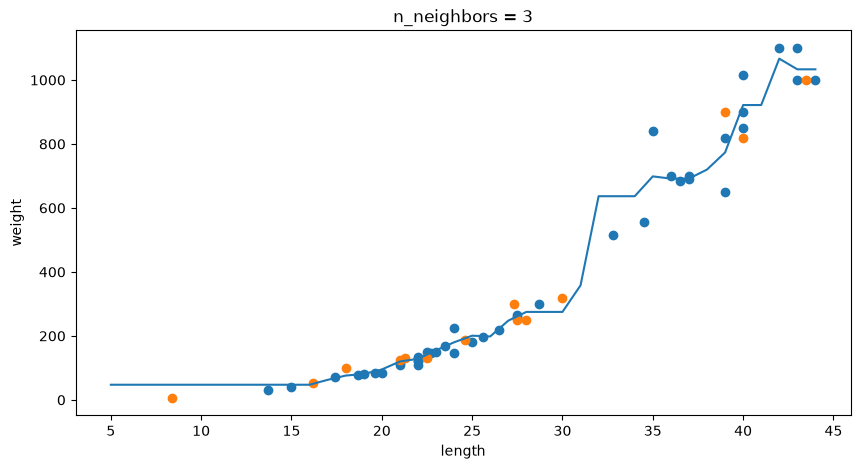

In [38]:
knr = KNeighborsRegressor()

# x좌표 ㅣ 5 ~ 45
x = np.arange(5,45).reshape(-1,1)

knr.n_neighbors = 3
knr.fit(train_input, train_target)
print("k -> ", 3)
print("Train Score :", knr.score(train_input,train_target))
print("Test Score :", knr.score(test_input,test_target))
print("-"*120)

# 지정한 범위 x에 대한 예측 구하기
pred = knr.predict(x)

# 훈련세트와 검증세트의 예측 결과 그래프 그리기
plt.figure(figsize=(10,5))
plt.scatter(train_input,train_target)
plt.scatter(test_input,test_target)
plt.plot(x,pred)
plt.title('n_neighbors = 3')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

k ->  1
Train Score : 0.9852830341215901
Test Score : 0.991309195814175
------------------------------------------------------------------------------------------------------------------------


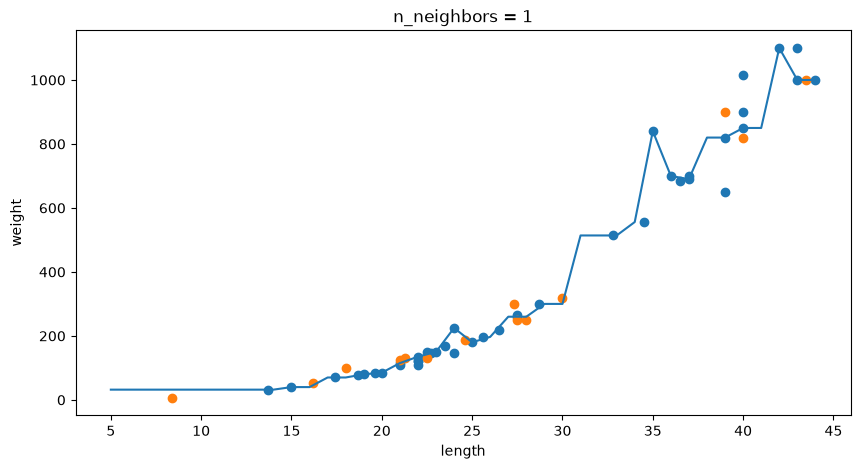

k ->  3
Train Score : 0.9804899950518966
Test Score : 0.9746459963987609
------------------------------------------------------------------------------------------------------------------------


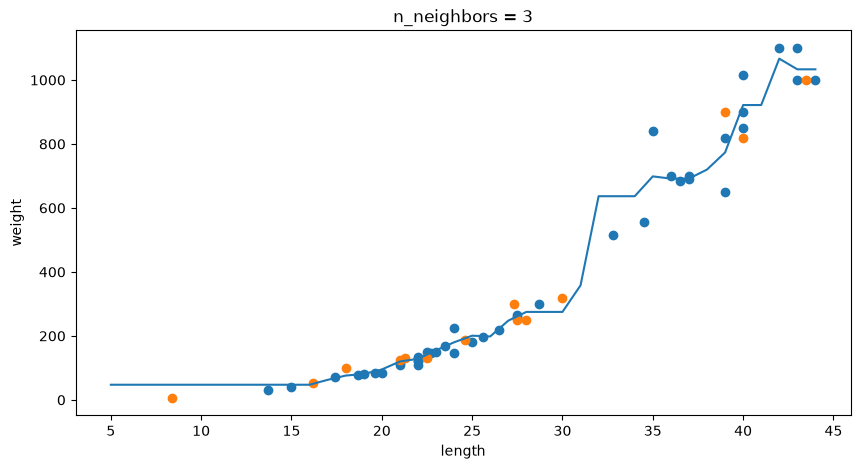

k ->  5
Train Score : 0.9698823289099254
Test Score : 0.992809406101064
------------------------------------------------------------------------------------------------------------------------


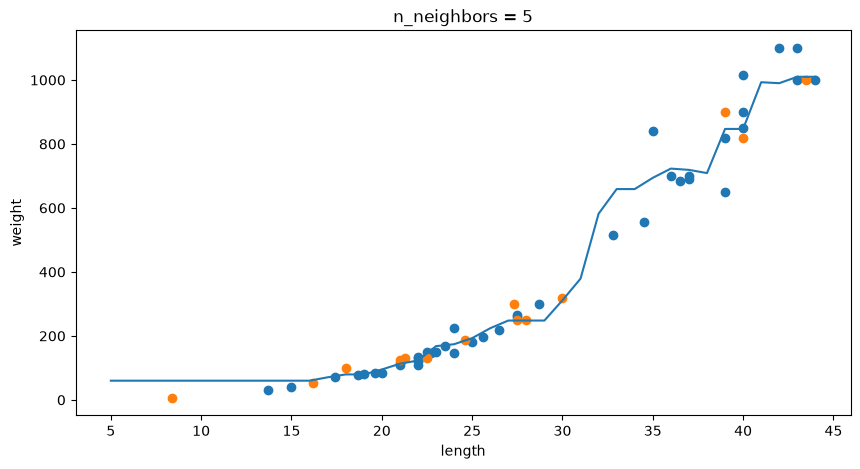

k ->  10
Train Score : 0.96164569026043
Test Score : 0.9737908255822255
------------------------------------------------------------------------------------------------------------------------


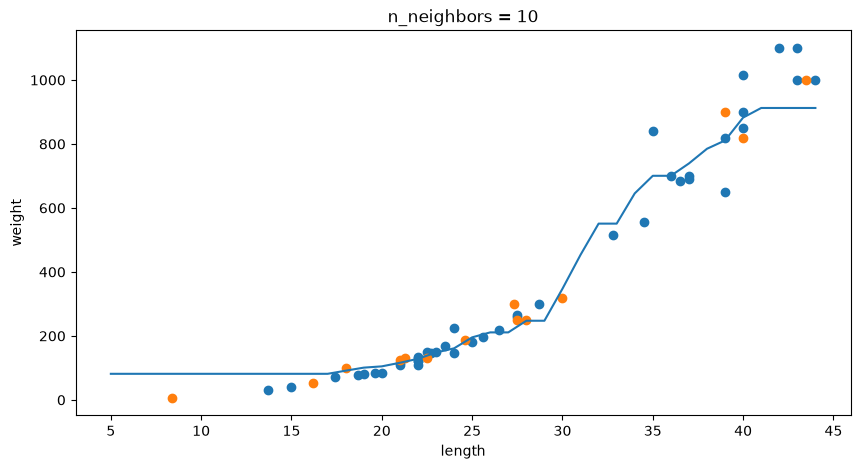

In [41]:
knr = KNeighborsRegressor()

# x좌표 ㅣ 5 ~ 45
x = np.arange(5,45).reshape(-1,1)
for n in [1,3,5,10]:
   knr.n_neighbors = n
   knr.fit(train_input, train_target)
   print("k -> ", n)
   print("Train Score :", knr.score(train_input,train_target))
   print("Test Score :", knr.score(test_input,test_target))
   print("-"*120)

   # 지정한 범위 x에 대한 예측 구하기
   pred = knr.predict(x)

   # 훈련세트와 검증세트의 예측 결과 그래프 그리기
   plt.figure(figsize=(10,5))
   plt.scatter(train_input,train_target)
   plt.scatter(test_input,test_target)
   plt.plot(x,pred)
   plt.title(f'n_neighbors = {n}')
   plt.xlabel('length')
   plt.ylabel('weight')
   plt.show()